# Roteiro de Análise de Dados - Fórmula 1

Este notebook implementa as etapas sugeridas no roteiro de análise, cobrindo desde o carregamento dos dados até a aplicação de modelos de Machine Learning (Clusterização, Classificação e Regressão).

## 1. Configuração e Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

# Configurações de visualização
sns.set_palette("husl")
sns.set_style("whitegrid")
%matplotlib inline

Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

Vamos carregar os arquivos principais: `results.csv`, `races.csv`, `drivers.csv`, `constructors.csv` e `status.csv`.
Importante: O dataset usa `\N` para representar valores nulos.

In [3]:
base_path = 'data/'

try:
    results = pd.read_csv(base_path + 'results.csv', na_values='\\N')
    races = pd.read_csv(base_path + 'races.csv', na_values='\\N')
    drivers = pd.read_csv(base_path + 'drivers.csv', na_values='\\N')
    constructors = pd.read_csv(base_path + 'constructors.csv', na_values='\\N')
    status = pd.read_csv(base_path + 'status.csv', na_values='\\N')
    print("Arquivos CSV carregados com sucesso.")
except FileNotFoundError as e:
    print(f"Erro ao carregar arquivos: {e}")

Arquivos CSV carregados com sucesso.


In [4]:
# Merge dos Datasets para formar um DataFrame consolidado
# Juntando Resultados com Corridas (para pegar ano e circuito)
df = results.merge(races[['raceId', 'year', 'name', 'date', 'circuitId']], on='raceId', how='left')

# Juntando com Pilotos (nome, nacionalidade)
df = df.merge(drivers[['driverId', 'driverRef', 'nationality', 'dob']], on='driverId', how='left')

# Juntando com Construtores (equipes)
df = df.merge(constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', how='left', suffixes=('_driver', '_team'))

# Juntando com Status (causa do fim da corrida)
df = df.merge(status[['statusId', 'status']], on='statusId', how='left')

# Limpeza Rápida
# Convertendo posição para numérico (substituindo o que não for numérico por NaN, embora ja tenhamos tratado \N)
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')

print(f"Dataset consolidado criado. Formato: {df.shape}")
df.head()

Dataset consolidado criado. Formato: (26759, 28)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year,name,date,circuitId,driverRef,nationality_driver,dob,constructorRef,nationality_team,status
0,1,18,1,1,22.0,1,1.0,1,1,10.0,...,2008,Australian Grand Prix,2008-03-16,1,hamilton,British,1985-01-07,mclaren,British,Finished
1,2,18,2,2,3.0,5,2.0,2,2,8.0,...,2008,Australian Grand Prix,2008-03-16,1,heidfeld,German,1977-05-10,bmw_sauber,German,Finished
2,3,18,3,3,7.0,7,3.0,3,3,6.0,...,2008,Australian Grand Prix,2008-03-16,1,rosberg,German,1985-06-27,williams,British,Finished
3,4,18,4,4,5.0,11,4.0,4,4,5.0,...,2008,Australian Grand Prix,2008-03-16,1,alonso,Spanish,1981-07-29,renault,French,Finished
4,5,18,5,1,23.0,3,5.0,5,5,4.0,...,2008,Australian Grand Prix,2008-03-16,1,kovalainen,Finnish,1981-10-19,mclaren,British,Finished


## 3. Análise Exploratória de Dados (EDA)

/var/folders/lx/67ytrby50477p576jb5_3xgr0000gn/T/ipykernel_11314/606776278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wins.values, y=wins.index, palette='viridis')


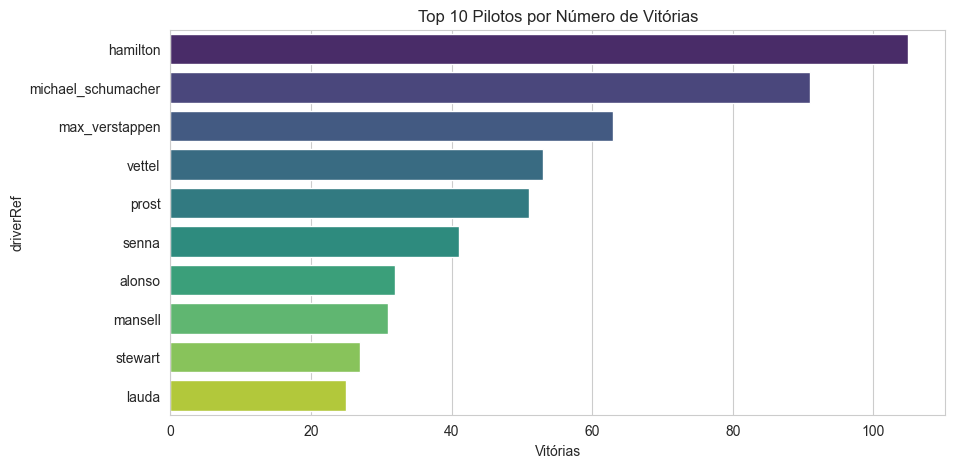

In [5]:
# Top 10 Pilotos com mais vitórias na base de dados
wins = df[df['positionOrder'] == 1].groupby('driverRef')['year'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=wins.values, y=wins.index, palette='viridis')
plt.title('Top 10 Pilotos por Número de Vitórias')
plt.xlabel('Vitórias')
plt.show()

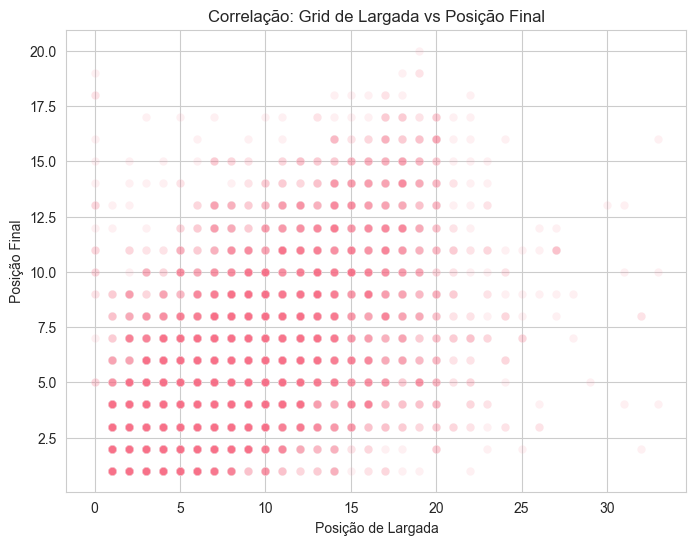

Correlação entre Largada e Chegada: 0.63


In [6]:
# Correlação entre Posição de Largada (Grid) e Posição Final
# Filtrando apenas corridas completadas (sem abandonos)
df_finished = df[df['statusId'] == 1] # statusId 1 geralmente é 'Finished'

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_finished, x='grid', y='positionOrder', alpha=0.1)
plt.title('Correlação: Grid de Largada vs Posição Final')
plt.xlabel('Posição de Largada')
plt.ylabel('Posição Final')
plt.show()

corr = df_finished[['grid', 'positionOrder']].corr().iloc[0,1]
print(f"Correlação entre Largada e Chegada: {corr:.2f}")

## 4. Clusterização (Modelagem Não-Supervisionada)
**Objetivo:** Agrupar pilotos com base em suas estatísticas médias (Posição média, Pontos médios).

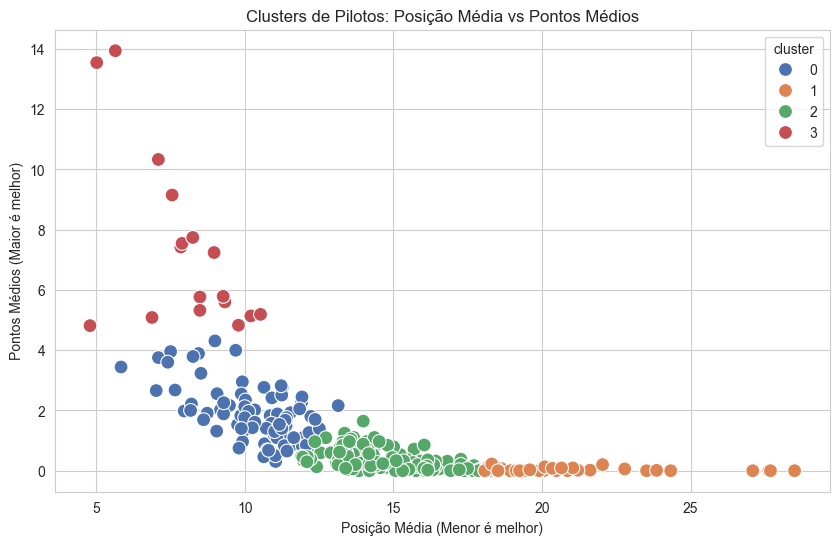

In [7]:
# Criando métricas por piloto
driver_stats = df.groupby('driverRef').agg({
    'positionOrder': 'mean',
    'points': 'mean',
    'raceId': 'count'
}).reset_index()

# Filtrando pilotos com poucas corridas (> 20 corridas) para evitar ruído
driver_stats = driver_stats[driver_stats['raceId'] > 20]

# Preparando dados para o modelo
X_cluster = driver_stats[['positionOrder', 'points']]

# Normalização (Importante para K-Means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Aplicando K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
driver_stats['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Visualizando os Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=driver_stats, x='positionOrder', y='points', hue='cluster', palette='deep', s=100)
plt.title('Clusters de Pilotos: Posição Média vs Pontos Médios')
plt.xlabel('Posição Média (Menor é melhor)')
plt.ylabel('Pontos Médios (Maior é melhor)')
plt.show()

## 5. Classificação (Modelagem Supervisionada)
**Objetivo:** Prever se um piloto terminará no **Pódio (Top 3)**.

In [8]:
# Criando a variável alvo (Target)
df['is_podium'] = df['positionOrder'].apply(lambda x: 1 if x <= 3 else 0)

# Selecionando Features
# Vamos usar: Grid, Ano (para capturar tendências temporais) e Equipe
le_team = LabelEncoder()
df['team_code'] = le_team.fit_transform(df['constructorRef'].astype(str))

features = ['grid', 'team_code', 'year']

# Limpando NaNs nas features
df_model = df.dropna(subset=features)

X = df_model[features]
y = df_model['is_podium']

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Avaliação
y_pred = clf.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.8786746387643248

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      7001
           1       0.53      0.47      0.50      1027

    accuracy                           0.88      8028
   macro avg       0.73      0.70      0.71      8028
weighted avg       0.87      0.88      0.88      8028



## 6. Regressão (Modelagem Supervisionada)
**Objetivo:** Prever a quantidade de **pontos** obtidos na corrida.

RMSE: 3.87
R2 Score: 0.22


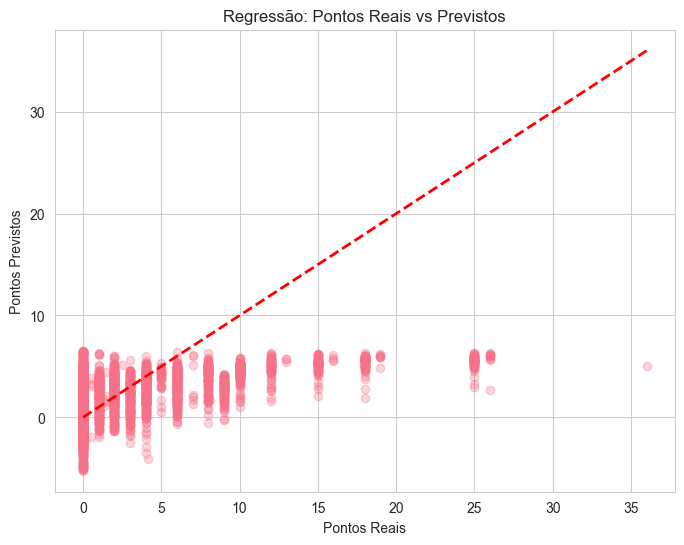

In [9]:
# Target: points
# Usando as mesmas features da classificação
y_reg = df_model['points']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.3, random_state=42)

# Modelo Regressão Linear
reg = LinearRegression()
reg.fit(X_train_reg, y_train_reg)

# Predição
y_pred_reg = reg.predict(X_test_reg)

# Avaliação
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot Real vs Previsto
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Pontos Reais')
plt.ylabel('Pontos Previstos')
plt.title('Regressão: Pontos Reais vs Previstos')
plt.show()